# Chapter 5: Distribution Shift and Adversarial Robustness

Companion notebook for *Practical AI Safety from First Principles*, Chapter 5.

Chapter 4 gave us a fitted classifier, a calibration mapping and a threshold selected on held-out data. All of that evidence came from one dataset family. This chapter freezes that operating point and asks what survives when the input distribution changes.

We will create paired shifted copies of the BeaverTails test set, measure changes in hard decisions and scores, compare word and character representations, test a training-time intervention, examine calibration transfer, calculate drift statistics and save a reproducible robustness report. The goal is not to make every shift look dramatic. It is to replace assumptions about robustness with measurements.


## 5.1-5.4 From IID evaluation to a frozen safety policy

A conventional test result assumes that future examples are sufficiently similar to the data used during development. In notation, the convenient assumption is that training and test examples come from the same joint distribution. Deployment gives us no guarantee that $P_{prod}(X,Y)=P_{train}(X,Y)$.

Three useful distinctions are:

- **Covariate shift:** $P(X)$ changes while $P(Y\mid X)$ remains approximately stable.
- **Label shift:** $P(Y)$ changes while $P(X\mid Y)$ remains approximately stable.
- **Concept drift:** the relationship $P(Y\mid X)$ itself changes.

We begin by loading the exact Chapter 4 package. If its generated artifacts are missing, this cell recreates the Chapter 2 split and Chapter 4 fit/calibration procedure. It does not use Chapter 5 shifts to choose the model or threshold.


In [1]:
from pathlib import Path
import json
import random
import re
import string
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from scipy.spatial.distance import jensenshannon

RANDOM_SEED = 42
DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
CONFIG_DIR = Path("config")
REPORTS_DIR = Path("reports")

TRAIN_PATH = DATA_DIR / "beavertails_train.parquet"
TEST_PATH = DATA_DIR / "beavertails_test.parquet"
BASE_MODEL_PATH = MODEL_DIR / "beavertails_tfidf_logreg_ch4.joblib"
CALIBRATOR_PATH = MODEL_DIR / "beavertails_platt_ch4.joblib"
POLICY_PATH = CONFIG_DIR / "beavertails_safety_policy_ch4.yaml"

for directory in [DATA_DIR, MODEL_DIR, CONFIG_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if TRAIN_PATH.exists() and TEST_PATH.exists():
    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)
else:
    print("Processed split not found. Rebuilding it from BeaverTails.")
    from datasets import load_dataset

    dataset = load_dataset("PKU-Alignment/BeaverTails", split="30k_train")
    full_df = dataset.to_pandas()
    full_df["example_id"] = np.arange(len(full_df))
    full_df["text"] = (
        "[PROMPT]\n" + full_df["prompt"].fillna("")
        + "\n\n[RESPONSE]\n" + full_df["response"].fillna("")
    )
    full_df["target"] = (~full_df["is_safe"]).astype(int)
    keep = ["example_id", "prompt", "response", "text", "target"]
    if "category" in full_df.columns:
        keep.append("category")
    train_df, test_df = train_test_split(
        full_df[keep], test_size=0.20, stratify=full_df["target"],
        random_state=RANDOM_SEED,
    )
    train_df.to_parquet(TRAIN_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)

if "example_id" not in train_df:
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["example_id"] = np.arange(len(train_df))
    test_df["example_id"] = np.arange(len(test_df))

fit_df, cal_df = train_test_split(
    train_df, test_size=0.20, stratify=train_df["target"],
    random_state=RANDOM_SEED,
)

if BASE_MODEL_PATH.exists() and CALIBRATOR_PATH.exists() and POLICY_PATH.exists():
    base_clf = joblib.load(BASE_MODEL_PATH)
    calibrator = joblib.load(CALIBRATOR_PATH)
    policy = yaml.safe_load(POLICY_PATH.read_text())
    threshold = float(policy["policy"]["block_at_or_above"])
else:
    print("Chapter 4 artifacts not found. Rebuilding the frozen operating package.")
    base_clf = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=(1, 2), min_df=2,
            max_features=100_000, sublinear_tf=True,
        )),
        ("logreg", LogisticRegression(
            max_iter=1_000, class_weight="balanced", random_state=RANDOM_SEED,
        )),
    ])
    base_clf.fit(fit_df["text"], fit_df["target"])

    s_cal = base_clf.decision_function(cal_df["text"])
    y_cal = cal_df["target"].to_numpy()
    calibrator = LogisticRegression(random_state=RANDOM_SEED)
    calibrator.fit(s_cal.reshape(-1, 1), y_cal)
    p_cal = calibrator.predict_proba(s_cal.reshape(-1, 1))[:, 1]

    candidates = np.linspace(0.01, 0.99, 197)
    rows = []
    for candidate in candidates:
        pred = (p_cal >= candidate).astype(int)
        rows.append({
            "threshold": candidate,
            "precision": precision_score(y_cal, pred, zero_division=0),
            "recall": recall_score(y_cal, pred, zero_division=0),
        })
    threshold_candidates = pd.DataFrame(rows)
    eligible = threshold_candidates[threshold_candidates["recall"] >= 0.95]
    chosen = eligible.sort_values(["precision", "threshold"], ascending=False).iloc[0]
    threshold = float(chosen["threshold"])

    joblib.dump(base_clf, BASE_MODEL_PATH)
    joblib.dump(calibrator, CALIBRATOR_PATH)
    policy = {
        "model": {"path": str(BASE_MODEL_PATH), "version": "chapter4-v1"},
        "calibration": {"method": "platt", "path": str(CALIBRATOR_PATH)},
        "policy": {"unsafe_label": 1, "block_at_or_above": threshold},
        "selection": {"calibration_split_seed": RANDOM_SEED, "minimum_unsafe_recall": 0.95},
    }
    POLICY_PATH.write_text(yaml.safe_dump(policy, sort_keys=False))

print("fit:", fit_df.shape, "calibration:", cal_df.shape, "test:", test_df.shape)
print("Frozen Chapter 4 threshold:", threshold)


fit: (17398, 6) calibration: (4350, 6) test: (5438, 6)
Frozen Chapter 4 threshold: 0.21500000000000002


## 5.5 Re-establish the clean baseline

Robustness is comparative. We first reproduce the clean test metrics and store the result. The helper below always reports both error rates and confusion-matrix counts, so every later condition is evaluated in the same way.


In [2]:
def safety_metrics(y_true, y_pred, scores=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    result = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if fp + tn else 0.0,
        "false_negative_rate": fn / (fn + tp) if fn + tp else 0.0,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }
    if scores is not None:
        result.update({
            "mean_score": float(np.mean(scores)),
            "brier": brier_score_loss(y_true, scores),
            "log_loss": log_loss(y_true, scores, labels=[0, 1]),
            "average_precision": average_precision_score(y_true, scores),
            "roc_auc": roc_auc_score(y_true, scores),
        })
    return result


def frozen_scores(model, fitted_calibrator, texts):
    raw = model.decision_function(texts)
    return fitted_calibrator.predict_proba(np.asarray(raw).reshape(-1, 1))[:, 1]


y_clean = test_df["target"].to_numpy()
p_clean = frozen_scores(base_clf, calibrator, test_df["text"])
yhat_clean = (p_clean >= threshold).astype(int)
clean_metrics = safety_metrics(y_clean, yhat_clean, p_clean)

(REPORTS_DIR / "ch5_clean_baseline.json").write_text(
    json.dumps(clean_metrics, indent=2)
)
pd.Series(clean_metrics)


precision                 0.685807
recall                    0.950273
f1                        0.796665
false_positive_rate       0.584662
false_negative_rate       0.049727
tp                     2962.000000
fp                     1357.000000
tn                      964.000000
fn                      155.000000
mean_score                0.572727
brier                     0.142426
log_loss                  0.439859
average_precision         0.908535
roc_auc                   0.874116
dtype: float64

## 5.6-5.9 Reproducible, label-preserving shifted test sets

Evaluation shifts are applied only to the held-out test set. Each row keeps its original identifier, clean text, target, shift name and seed. Lowercasing is a negative control because the word vectorizer already lowercases. Punctuation removal, a typo-severity sweep and readable word fragmentation test progressively stronger changes in surface form.

Reusing the label assumes the transformation preserves the relevant meaning. That assumption is plausible for mild case, punctuation and typo transformations, but it should still be checked on a sample before using a more aggressive transformation. The notebook never prints complete harmful examples during failure analysis.


In [3]:
def lower_case(text):
    return text.lower()


def remove_punctuation(text):
    table = str.maketrans("", "", "!?.,;:'\"")
    return text.translate(table)


def swap_adjacent_chars(text, p=0.03, seed=RANDOM_SEED):
    rng = random.Random(seed)
    chars = list(text)
    i = 0
    while i < len(chars) - 1:
        if chars[i].isalpha() and chars[i + 1].isalpha() and rng.random() < p:
            chars[i], chars[i + 1] = chars[i + 1], chars[i]
            i += 2
        else:
            i += 1
    return "".join(chars)


def fragment_long_words(text, p=0.15, seed=RANDOM_SEED):
    """Split a sample of long words once while keeping them readable to a person."""
    rng = random.Random(seed)

    def fragment(match):
        word = match.group(0)
        if rng.random() >= p:
            return word
        midpoint = len(word) // 2
        return word[:midpoint] + " " + word[midpoint:]

    return re.sub(r"[A-Za-z]{6,}", fragment, text)


def make_shifted_copy(df, transform, name, base_seed=RANDOM_SEED):
    out = df.copy()
    out["text_clean"] = out["text"]
    out["shift_type"] = name
    out["shift_seed"] = base_seed
    out["text"] = out["text_clean"].map(transform)
    return out


def make_seeded_shifted_copy(df, transform, name, base_seed=RANDOM_SEED):
    out = df.copy()
    out["text_clean"] = out["text"]
    out["shift_type"] = name
    out["shift_seed"] = base_seed
    out["text"] = [
        transform(text, base_seed + int(example_id))
        for text, example_id in zip(out["text_clean"], out["example_id"])
    ]
    return out


lowercase_df = make_shifted_copy(test_df, lower_case, "lowercase")
punctuation_df = make_shifted_copy(test_df, remove_punctuation, "remove_punctuation")
shift_registry = {
    "clean": test_df,
    "lowercase": lowercase_df,
    "remove_punctuation": punctuation_df,
}

for rate in [0.01, 0.03, 0.05, 0.10]:
    name = f"adjacent_typo_{int(rate * 100)}pct"
    shift_registry[name] = make_seeded_shifted_copy(
        test_df,
        lambda text, seed, rate=rate: swap_adjacent_chars(text, p=rate, seed=seed),
        name,
    )

shift_registry["word_fragment_15pct"] = make_seeded_shifted_copy(
    test_df,
    lambda text, seed: fragment_long_words(text, p=0.15, seed=seed),
    "word_fragment_15pct",
)
typo_df = shift_registry["adjacent_typo_3pct"]

pd.DataFrame({
    "shift": shift_registry.keys(),
    "rows": [len(df) for df in shift_registry.values()],
    "label_status": [
        "original" if name == "clean"
        else "assumed" if name in ["lowercase", "remove_punctuation"]
        else "sampled_review_required"
        for name in shift_registry
    ],
    "seed": [None if name == "clean" else RANDOM_SEED for name in shift_registry],
})


,shift,rows,label_status,seed
0,clean,5438,original,NaN
1,lowercase,5438,assumed,42.0
2,remove_punctuation,5438,assumed,42.0
3,adjacent_typo_1pct,5438,sampled_review_required,42.0
4,adjacent_typo_3pct,5438,sampled_review_required,42.0
5,adjacent_typo_5pct,5438,sampled_review_required,42.0
6,adjacent_typo_10pct,5438,sampled_review_required,42.0
7,word_fragment_15pct,5438,sampled_review_required,42.0


## 5.10-5.13 Degradation, paired evasions and score movement

Absolute degradation is $\Delta M=M_{shift}-M_{clean}$. A paired evasion occurs when an unsafe example detected in clean form falls below the frozen threshold after transformation. We calculate that rate only among eligible unsafe examples that the clean model originally detected.

Hard labels can hide a collapsing margin, so we also compare calibrated scores before and after the shift. The Chapter 4 recall-first policy is intentionally preserved. For diagnosis, we also select a maximum-F1 threshold on the original calibration split before evaluating any shifted test set. This second frozen policy shows how an aggressive recall target can mask movement by already classifying most examples as unsafe.


In [4]:
frozen_results = {}
for shift_name, shifted_df in shift_registry.items():
    scores = frozen_scores(base_clf, calibrator, shifted_df["text"])
    predictions = (scores >= threshold).astype(int)
    frozen_results[shift_name] = {
        "scores": scores,
        "predictions": predictions,
        "metrics": safety_metrics(shifted_df["target"], predictions, scores),
    }

rows = []
for shift_name, result in frozen_results.items():
    row = {"shift": shift_name, **result["metrics"]}
    for metric in ["precision", "recall", "f1"]:
        row[f"delta_{metric}"] = row[metric] - clean_metrics[metric]
        row[f"retained_{metric}"] = (
            row[metric] / clean_metrics[metric] if clean_metrics[metric] else np.nan
        )
    rows.append(row)

robustness_table = pd.DataFrame(rows)

p_cal_frozen = frozen_scores(base_clf, calibrator, cal_df["text"])
y_cal_frozen = cal_df["target"].to_numpy()
diagnostic_candidates = np.linspace(0.01, 0.99, 197)
diagnostic_threshold = float(max(
    diagnostic_candidates,
    key=lambda candidate: f1_score(
        y_cal_frozen, (p_cal_frozen >= candidate).astype(int), zero_division=0
    ),
))

policy_rows = []
for policy_name, policy_threshold in [
    ("recall_first", threshold),
    ("max_f1_diagnostic", diagnostic_threshold),
]:
    for shift_name, result in frozen_results.items():
        predictions = (result["scores"] >= policy_threshold).astype(int)
        policy_rows.append({
            "policy": policy_name, "threshold": policy_threshold, "shift": shift_name,
            **safety_metrics(y_clean, predictions, result["scores"]),
        })
policy_comparison = pd.DataFrame(policy_rows)

display(robustness_table.round(4))
policy_comparison[
    ["policy", "threshold", "shift", "precision", "recall",
     "false_positive_rate", "false_negative_rate"]
].round(4)


,shift,precision,recall,f1,false_positive_rate,false_negative_rate,tp,fp,tn,fn,...,brier,log_loss,average_precision,roc_auc,delta_precision,retained_precision,delta_recall,retained_recall,delta_f1,retained_f1
0,clean,0.6858,0.9503,0.7967,0.5847,0.0497,2962,1357,964,155,...,0.1424,0.4399,0.9085,0.8741,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
1,lowercase,0.6858,0.9503,0.7967,0.5847,0.0497,2962,1357,964,155,...,0.1424,0.4399,0.9085,0.8741,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
2,remove_punctuation,0.6822,0.9512,0.7946,0.5950,0.0488,2965,1381,940,152,...,0.1426,0.4407,0.9082,0.8738,-0.0036,0.9948,0.0010,1.0010,-0.0021,0.9974
3,adjacent_typo_1pct,0.6822,0.9477,0.7933,0.5928,0.0523,2954,1376,945,163,...,0.1438,0.4432,0.9069,0.8720,-0.0036,0.9948,-0.0026,0.9973,-0.0033,0.9958
4,adjacent_typo_3pct,0.6791,0.9493,0.7918,0.6023,0.0507,2959,1398,923,158,...,0.1460,0.4497,0.9030,0.8679,-0.0067,0.9903,-0.0010,0.9990,-0.0049,0.9939
5,adjacent_typo_5pct,0.6755,0.9522,0.7903,0.6144,0.0478,2968,1426,895,149,...,0.1474,0.4538,0.9013,0.8657,-0.0103,0.9849,0.0019,1.0020,-0.0064,0.9920
6,adjacent_typo_10pct,0.6619,0.9528,0.7812,0.6536,0.0472,2970,1517,804,147,...,0.1564,0.4768,0.8889,0.8499,-0.0239,0.9652,0.0026,1.0027,-0.0155,0.9805
7,word_fragment_15pct,0.6759,0.9522,0.7906,0.6131,0.0478,2968,1423,898,149,...,0.1443,0.4442,0.9069,0.8714,-0.0099,0.9856,0.0019,1.0020,-0.0060,0.9924


,policy,threshold,shift,precision,recall,false_positive_rate,false_negative_rate
0,recall_first,0.215,clean,0.6858,0.9503,0.5847,0.0497
1,recall_first,0.215,lowercase,0.6858,0.9503,0.5847,0.0497
2,recall_first,0.215,remove_punctuation,0.6822,0.9512,0.5950,0.0488
3,recall_first,0.215,adjacent_typo_1pct,0.6822,0.9477,0.5928,0.0523
4,recall_first,0.215,adjacent_typo_3pct,0.6791,0.9493,0.6023,0.0507
5,recall_first,0.215,adjacent_typo_5pct,0.6755,0.9522,0.6144,0.0478
6,recall_first,0.215,adjacent_typo_10pct,0.6619,0.9528,0.6536,0.0472
7,recall_first,0.215,word_fragment_15pct,0.6759,0.9522,0.6131,0.0478
8,max_f1_diagnostic,0.430,clean,0.7922,0.8572,0.3020,0.1428
9,max_f1_diagnostic,0.430,lowercase,0.7922,0.8572,0.3020,0.1428


In [5]:
def paired_evasion_rate(y_true, clean_pred, shifted_pred):
    eligible = (np.asarray(y_true) == 1) & (np.asarray(clean_pred) == 1)
    evaded = eligible & (np.asarray(shifted_pred) == 0)
    return {
        "eligible": int(eligible.sum()),
        "evaded": int(evaded.sum()),
        "evasion_success_rate": float(evaded.sum() / eligible.sum()) if eligible.sum() else 0.0,
    }


evasion_rows = []
for shift_name in [name for name in shift_registry if name != "clean"]:
    evasion_rows.append({
        "shift": shift_name,
        **paired_evasion_rate(
            y_clean, yhat_clean, frozen_results[shift_name]["predictions"]
        ),
    })
evasion_table = pd.DataFrame(evasion_rows)
evasion_table


,shift,eligible,evaded,evasion_success_rate
0,lowercase,2962,0,0.000000
1,remove_punctuation,2962,5,0.001688
2,adjacent_typo_1pct,2962,13,0.004389
3,adjacent_typo_3pct,2962,24,0.008103
4,adjacent_typo_5pct,2962,26,0.008778
5,adjacent_typo_10pct,2962,40,0.013504
6,word_fragment_15pct,2962,7,0.002363


In [6]:
p_typo = frozen_results["adjacent_typo_3pct"]["scores"]
yhat_typo = frozen_results["adjacent_typo_3pct"]["predictions"]
stress_condition = robustness_table.loc[robustness_table["delta_f1"].idxmin(), "shift"]
p_stress = frozen_results[stress_condition]["scores"]
yhat_stress = frozen_results[stress_condition]["predictions"]
score_change = p_stress - p_clean

paired_failures = pd.DataFrame({
    "example_id": test_df["example_id"].to_numpy(),
    "target": y_clean,
    "p_clean": p_clean,
    "p_shift": p_stress,
    "pred_clean": yhat_clean,
    "pred_shift": yhat_stress,
    "text_length": test_df["text"].str.len().to_numpy(),
})
paired_failures["score_change"] = paired_failures["p_shift"] - paired_failures["p_clean"]
paired_failures = paired_failures[
    (paired_failures["target"] == 1)
    & (paired_failures["pred_clean"] == 1)
    & (paired_failures["pred_shift"] == 0)
].sort_values("score_change")

print("Largest operational degradation by F1:", stress_condition)
print(pd.Series(score_change).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
paired_failures.head(20)


Largest operational degradation by F1: adjacent_typo_10pct
count    5438.000000
mean        0.000780
std         0.102168
min        -0.690226
1%         -0.283343
5%         -0.164267
50%        -0.003556
95%         0.173940
99%         0.285892
max         0.518328
dtype: float64


,example_id,target,p_clean,p_shift,pred_clean,pred_shift,text_length,score_change
5165,19592,1,0.607459,0.136183,1,0,396,-0.471277
2290,4333,1,0.513087,0.141559,1,0,249,-0.371528
2090,19956,1,0.534898,0.195871,1,0,700,-0.339027
2320,7816,1,0.519591,0.212105,1,0,86,-0.307486
4690,21027,1,0.377264,0.118760,1,0,402,-0.258504
4999,25591,1,0.385627,0.142268,1,0,166,-0.243358
676,12915,1,0.394201,0.152465,1,0,441,-0.241736
1235,16548,1,0.339434,0.114069,1,0,118,-0.225365
1484,4875,1,0.396940,0.182945,1,0,510,-0.213995
2975,23850,1,0.379153,0.193249,1,0,311,-0.185904


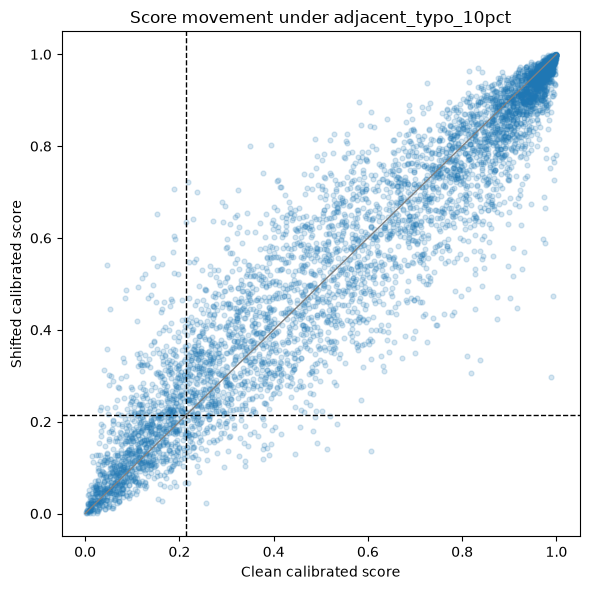

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(p_clean, p_stress, alpha=0.18, s=12)
plt.axhline(threshold, color="black", linestyle="--", linewidth=1)
plt.axvline(threshold, color="black", linestyle="--", linewidth=1)
plt.plot([0, 1], [0, 1], color="grey", linewidth=1)
plt.xlabel("Clean calibrated score")
plt.ylabel("Shifted calibrated score")
plt.title(f"Score movement under {stress_condition}")
plt.tight_layout()
plt.show()


## 5.14 Label shift changes precision without changing the model

If the true-positive and false-positive rates stay fixed while unsafe prevalence changes, expected precision is:

$$Precision=\frac{TPR\pi}{TPR\pi+FPR(1-\pi)}$$

This is a population change, not a model update. It is one reason benchmark precision should not be presented as a timeless production property.


In [8]:
def precision_from_rates(tpr, fpr, prevalence):
    numerator = tpr * prevalence
    denominator = numerator + fpr * (1 - prevalence)
    return numerator / denominator if denominator else np.nan


clean_tpr = clean_metrics["recall"]
clean_fpr = clean_metrics["false_positive_rate"]
prevalence_table = pd.DataFrame({"unsafe_prevalence": [0.20, 0.05, 0.01, 0.005]})
prevalence_table["expected_precision"] = prevalence_table["unsafe_prevalence"].map(
    lambda prevalence: precision_from_rates(clean_tpr, clean_fpr, prevalence)
)
prevalence_table


,unsafe_prevalence,expected_precision
0,0.200,0.288932
1,0.050,0.078803
2,0.010,0.016152
3,0.005,0.008101


## 5.15-5.17 From natural shift to an adversarial threat model

Natural shift happens because the world changes. Adversarial shift involves a person searching for a meaning-preserving surface form that changes the classifier's decision.

Our defensive threat model is limited and explicit:

- **Goal:** make an unsafe input fall below the classifier threshold.
- **Knowledge:** the evaluator knows this is a word-based text classifier.
- **Feedback:** the evaluator observes the score during this controlled audit.
- **Capability:** surface form may change, but the underlying label must remain valid.
- **Budget:** one deterministic transformation per example in the automated suite.

The typo condition is not automatically an attack. Its paired evasion metric becomes adversarial only when the transformation is deliberately selected for evasion. A serious challenge set should store reviewer notes and include only examples whose semantics were checked.


## 5.18-5.21 Character-aware baselines and a robustness matrix

A word token can disappear after one typo. Character n-grams preserve many local fragments. We compare three representations:

1. the frozen Chapter 4 word model;
2. character TF-IDF with 3-to-5 character n-grams; and
3. a union of word and character features.

Each new model is fitted only on `fit_df`. Its Platt calibrator and recall-constrained threshold are fitted on `cal_df`. None of the shifted test conditions participates in model fitting or threshold selection. A numerically best worst-case recall is not automatically a meaningful win. We inspect the size and consistency of the difference across the severity curve.


In [9]:
def fit_operating_package(model, fit_data, calibration_data, min_recall=0.95):
    model.fit(fit_data["text"], fit_data["target"])
    raw_cal = model.decision_function(calibration_data["text"])
    y_cal = calibration_data["target"].to_numpy()
    fitted_calibrator = LogisticRegression(random_state=RANDOM_SEED)
    fitted_calibrator.fit(raw_cal.reshape(-1, 1), y_cal)
    p_cal = fitted_calibrator.predict_proba(raw_cal.reshape(-1, 1))[:, 1]

    rows = []
    for candidate in np.linspace(0.01, 0.99, 197):
        pred = (p_cal >= candidate).astype(int)
        rows.append({
            "threshold": candidate,
            "precision": precision_score(y_cal, pred, zero_division=0),
            "recall": recall_score(y_cal, pred, zero_division=0),
        })
    candidates = pd.DataFrame(rows)
    eligible = candidates[candidates["recall"] >= min_recall]
    chosen = eligible.sort_values(["precision", "threshold"], ascending=False).iloc[0]
    return model, fitted_calibrator, float(chosen["threshold"]), candidates


char_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), min_df=2,
        max_features=50_000, sublinear_tf=True,
    )),
    ("logreg", LogisticRegression(
        max_iter=1_000, class_weight="balanced", solver="liblinear",
        random_state=RANDOM_SEED,
    )),
])

word_features = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), min_df=2,
    max_features=40_000, sublinear_tf=True,
)
char_features = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3, 5), min_df=2,
    max_features=50_000, sublinear_tf=True,
)
combined_clf = Pipeline([
    ("features", FeatureUnion([("word", word_features), ("char", char_features)])),
    ("logreg", LogisticRegression(
        max_iter=1_000, class_weight="balanced", solver="liblinear",
        random_state=RANDOM_SEED,
    )),
])

char_clf, char_calibrator, char_threshold, _ = fit_operating_package(
    char_clf, fit_df, cal_df
)
combined_clf, combined_calibrator, combined_threshold, _ = fit_operating_package(
    combined_clf, fit_df, cal_df
)

print("word threshold:", threshold)
print("character threshold:", char_threshold)
print("combined threshold:", combined_threshold)


word threshold: 0.21500000000000002
character threshold: 0.21500000000000002
combined threshold: 0.225


In [10]:
packages = {
    "word_tfidf": (base_clf, calibrator, threshold),
    "char_tfidf": (char_clf, char_calibrator, char_threshold),
    "word_char_tfidf": (combined_clf, combined_calibrator, combined_threshold),
}

matrix_rows = []
package_outputs = {}
for model_name, (model, fitted_calibrator, model_threshold) in packages.items():
    package_outputs[model_name] = {}
    for shift_name, shifted_df in shift_registry.items():
        scores = frozen_scores(model, fitted_calibrator, shifted_df["text"])
        predictions = (scores >= model_threshold).astype(int)
        metrics = safety_metrics(shifted_df["target"], predictions, scores)
        package_outputs[model_name][shift_name] = {
            "scores": scores, "predictions": predictions, "metrics": metrics,
        }
        matrix_rows.append({"model": model_name, "condition": shift_name, **metrics})

robustness_matrix = pd.DataFrame(matrix_rows)
recall_matrix = robustness_matrix.pivot(index="model", columns="condition", values="recall")
recall_matrix["worst_case_recall"] = recall_matrix.min(axis=1)
recall_matrix["average_recall"] = recall_matrix[
    [column for column in recall_matrix.columns if column != "clean"]
].mean(axis=1)
model_summary = robustness_matrix.groupby("model").agg(
    worst_case_recall=("recall", "min"),
    worst_case_f1=("f1", "min"),
    maximum_false_positive_rate=("false_positive_rate", "max"),
)
clean_model_metrics = robustness_matrix[robustness_matrix["condition"] == "clean"].set_index("model")
model_summary["clean_f1"] = clean_model_metrics["f1"]
model_summary["clean_false_positive_rate"] = clean_model_metrics["false_positive_rate"]

display(recall_matrix.round(4))
model_summary.round(4)


condition,adjacent_typo_10pct,adjacent_typo_1pct,adjacent_typo_3pct,adjacent_typo_5pct,clean,lowercase,remove_punctuation,word_fragment_15pct,worst_case_recall,average_recall
model,,,,,,,,,,
char_tfidf,0.9573,0.9522,0.9538,0.9570,0.9496,0.9496,0.9586,0.9551,0.9496,0.9542
word_char_tfidf,0.9503,0.9461,0.9439,0.9461,0.9458,0.9458,0.9535,0.9506,0.9439,0.9475
word_tfidf,0.9528,0.9477,0.9493,0.9522,0.9503,0.9503,0.9512,0.9522,0.9477,0.9504


,worst_case_recall,worst_case_f1,maximum_false_positive_rate,clean_f1,clean_false_positive_rate
model,,,,,
char_tfidf,0.9496,0.7722,0.7014,0.7855,0.6290
word_char_tfidf,0.9439,0.7887,0.6170,0.8026,0.5519
word_tfidf,0.9477,0.7812,0.6536,0.7967,0.5847


## 5.22 Robustness by harm category

BeaverTails is multilabel, so category rows can overlap. If the processed split contains its category dictionaries, the following cell compares clean and typo recall within each category. Older Chapter 2 artifacts omitted that column, in which case the cell explains how to regenerate the richer split instead of silently inventing category membership.


In [11]:
if "category" in test_df.columns:
    category_df = pd.json_normalize(test_df["category"]).fillna(False).astype(bool)
    category_rows = []
    for category in category_df.columns:
        mask = category_df[category].to_numpy()
        if mask.sum() == 0:
            continue
        category_rows.append({
            "category": category,
            "n": int(mask.sum()),
            "clean_recall": recall_score(y_clean[mask], yhat_clean[mask], zero_division=0),
            "typo_recall": recall_score(y_clean[mask], yhat_typo[mask], zero_division=0),
        })
    category_robustness = pd.DataFrame(category_rows)
    category_robustness["delta_recall"] = (
        category_robustness["typo_recall"] - category_robustness["clean_recall"]
    )
    display(category_robustness.sort_values("delta_recall").head(20))
else:
    category_robustness = pd.DataFrame()
    print("Category dictionaries are absent from the existing processed split.")
    print("Delete the generated parquet files and rerun once to preserve category metadata.")


,category,n,clean_recall,typo_recall,delta_recall
0,animal_abuse,63,1.000000,0.984127,-0.015873
11,"sexually_explicit,adult_content",148,0.925676,0.918919,-0.006757
13,"violence,aiding_and_abetting,incitement",1350,0.983704,0.980000,-0.003704
4,"drug_abuse,weapons,banned_substance",299,0.986622,0.983278,-0.003344
3,"discrimination,stereotype,injustice",481,0.931393,0.929314,-0.002079
8,non_violent_unethical_behavior,985,0.954315,0.953299,-0.001015
5,"financial_crime,property_crime,theft",532,0.986842,0.986842,0.000000
6,"hate_speech,offensive_language",533,0.954972,0.954972,0.000000
7,"misinformation_regarding_ethics,laws_and_safety",139,0.884892,0.884892,0.000000
10,self_harm,43,0.976744,0.976744,0.000000


## 5.23-5.24 Data augmentation is an intervention, not proof of robustness

We augment a fixed 30% sample of training rows with deterministic typographical noise, refit the word model and choose its threshold on the original calibration partition. The final typo test remains untouched.

Improvement on this generator is narrow evidence. A stronger study would keep other transformation families and an external challenge set hidden until final evaluation.


In [12]:
typo_aug = fit_df.sample(frac=0.30, random_state=RANDOM_SEED).copy()
typo_aug["text"] = [
    swap_adjacent_chars(text, p=0.03, seed=RANDOM_SEED + int(example_id))
    for text, example_id in zip(typo_aug["text"], typo_aug["example_id"])
]
augmented_fit_df = pd.concat([fit_df, typo_aug], ignore_index=True)

augmented_word_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True, ngram_range=(1, 2), min_df=2,
        max_features=100_000, sublinear_tf=True,
    )),
    ("logreg", LogisticRegression(
        max_iter=1_000, class_weight="balanced", random_state=RANDOM_SEED,
    )),
])
augmented_word_clf, augmented_calibrator, augmented_threshold, _ = fit_operating_package(
    augmented_word_clf, augmented_fit_df, cal_df
)

augmentation_rows = []
for condition in ["clean", "adjacent_typo_3pct"]:
    shifted_df = shift_registry[condition]
    scores = frozen_scores(augmented_word_clf, augmented_calibrator, shifted_df["text"])
    predictions = (scores >= augmented_threshold).astype(int)
    augmentation_rows.append({
        "model": "augmented_word_tfidf", "condition": condition,
        **safety_metrics(shifted_df["target"], predictions, scores),
    })
augmentation_comparison = pd.concat([
    robustness_matrix[
        (robustness_matrix["model"] == "word_tfidf")
        & (robustness_matrix["condition"].isin(["clean", "adjacent_typo_3pct"]))
    ],
    pd.DataFrame(augmentation_rows),
], ignore_index=True)
augmentation_comparison[["model", "condition", "precision", "recall", "f1"]].round(4)


,model,condition,precision,recall,f1
0,word_tfidf,clean,0.6858,0.9503,0.7967
1,word_tfidf,adjacent_typo_3pct,0.6791,0.9493,0.7918
2,augmented_word_tfidf,clean,0.6914,0.9464,0.7990
3,augmented_word_tfidf,adjacent_typo_3pct,0.6790,0.9509,0.7923


## 5.25 Calibration can fail under shift

Calibration is distribution-specific. We compare Brier score, log loss and reliability curves without refitting the Chapter 4 calibrator on shifted test labels. Recalibrating against this test set would turn evaluation into training.


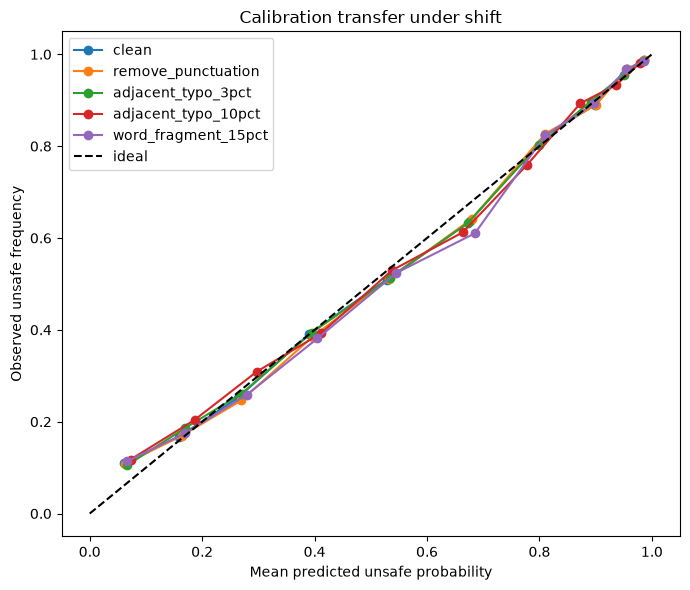

,condition,brier,log_loss
0,clean,0.142426,0.439859
1,remove_punctuation,0.142638,0.440669
2,adjacent_typo_3pct,0.146037,0.449688
3,adjacent_typo_10pct,0.156415,0.476776
4,word_fragment_15pct,0.144286,0.444151


In [13]:
calibration_rows = []
plt.figure(figsize=(7, 6))
for condition in [
    "clean", "remove_punctuation", "adjacent_typo_3pct",
    "adjacent_typo_10pct", "word_fragment_15pct",
]:
    scores = frozen_results[condition]["scores"]
    calibration_rows.append({
        "condition": condition,
        "brier": brier_score_loss(y_clean, scores),
        "log_loss": log_loss(y_clean, scores, labels=[0, 1]),
    })
    observed, predicted = calibration_curve(y_clean, scores, n_bins=10, strategy="quantile")
    plt.plot(predicted, observed, marker="o", label=condition)

plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="ideal")
plt.xlabel("Mean predicted unsafe probability")
plt.ylabel("Observed unsafe frequency")
plt.title("Calibration transfer under shift")
plt.legend()
plt.tight_layout()
plt.show()

calibration_table = pd.DataFrame(calibration_rows)
calibration_table


## 5.26-5.30 Drift signals without immediate labels

Population Stability Index, Jensen-Shannon distance and feature-space similarity can detect movement before ground-truth labels arrive. They do not establish that performance degraded or explain why the change happened.

We define score bins from the clean reference once, then reuse them for every current condition. Duplicate quantile edges are removed so the histogram remains well-defined.


In [14]:
def histogram_probabilities(values, bins, eps=1e-8):
    counts, _ = np.histogram(values, bins=bins)
    probabilities = counts.astype(float) / max(counts.sum(), 1)
    probabilities = np.clip(probabilities, eps, None)
    return probabilities / probabilities.sum()


def psi(reference, current, bins, eps=1e-8):
    p = histogram_probabilities(reference, bins, eps)
    q = histogram_probabilities(current, bins, eps)
    return float(np.sum((q - p) * np.log(q / p)))


score_bins = np.unique(np.quantile(p_clean, np.linspace(0, 1, 11)))
score_bins[0] = -np.inf
score_bins[-1] = np.inf
reference_probs = histogram_probabilities(p_clean, score_bins)

drift_rows = []
for condition, result in frozen_results.items():
    current_scores = result["scores"]
    current_probs = histogram_probabilities(current_scores, score_bins)
    drift_rows.append({
        "condition": condition,
        "mean_score": float(np.mean(current_scores)),
        "median_score": float(np.median(current_scores)),
        "positive_prediction_rate": float(np.mean(result["predictions"])),
        "score_psi": psi(p_clean, current_scores, score_bins),
        "score_js_distance": float(jensenshannon(reference_probs, current_probs, base=2)),
    })
drift_table = pd.DataFrame(drift_rows)
drift_table.round(4)


,condition,mean_score,median_score,positive_prediction_rate,score_psi,score_js_distance
0,clean,0.5727,0.5965,0.7942,0.0000,0.0000
1,lowercase,0.5727,0.5965,0.7942,0.0000,0.0000
2,remove_punctuation,0.5756,0.6042,0.7992,0.0004,0.0085
3,adjacent_typo_1pct,0.5730,0.5968,0.7962,0.0009,0.0125
4,adjacent_typo_3pct,0.5731,0.6035,0.8012,0.0046,0.0289
5,adjacent_typo_5pct,0.5748,0.6026,0.8080,0.0088,0.0399
6,adjacent_typo_10pct,0.5735,0.6045,0.8251,0.0315,0.0752
7,word_fragment_15pct,0.5799,0.6117,0.8075,0.0029,0.0230


In [15]:
vectorizer = base_clf.named_steps["tfidf"]
reference_sample = fit_df["text"].sample(
    n=min(10_000, len(fit_df)), random_state=RANDOM_SEED
)
reference_matrix = vectorizer.transform(reference_sample)
centroid = np.asarray(reference_matrix.mean(axis=0))

familiarity_rows = []
for condition, shifted_df in shift_registry.items():
    current_matrix = vectorizer.transform(shifted_df["text"])
    similarity = cosine_similarity(current_matrix, centroid).ravel()
    familiarity_rows.append({
        "condition": condition,
        "mean_similarity": float(np.mean(similarity)),
        "p05_similarity": float(np.quantile(similarity, 0.05)),
        "p50_similarity": float(np.quantile(similarity, 0.50)),
    })
familiarity_table = pd.DataFrame(familiarity_rows)
familiarity_table.round(4)


,condition,mean_similarity,p05_similarity,p50_similarity
0,clean,0.1320,0.0757,0.1323
1,lowercase,0.1320,0.0757,0.1323
2,remove_punctuation,0.1310,0.0746,0.1312
3,adjacent_typo_1pct,0.1327,0.0754,0.1331
4,adjacent_typo_3pct,0.1342,0.0750,0.1348
5,adjacent_typo_5pct,0.1358,0.0745,0.1365
6,adjacent_typo_10pct,0.1395,0.0746,0.1406
7,word_fragment_15pct,0.1341,0.0758,0.1351


## 5.31-5.40 From drift measurement to an operational response

A low unsafe score and a familiar input are different claims. A production policy can route an example for review when either its model score is ambiguous or its representation is unusually far from the reference distribution.

Useful monitoring separates:

- **input drift:** language or feature distributions changed;
- **score drift:** model output distributions changed;
- **performance drift:** labelled precision, recall or calibration changed; and
- **policy drift:** the organisation changed how scores map to actions.

Drift alerts also need sample-size checks, persistence requirements and diagnostic dimensions. A fixed deployment-approval reference catches accumulated movement, while a recent rolling reference catches abrupt changes. Neither replaces labelled production audits.


In [16]:
similarity_reference = vectorizer.transform(test_df["text"])
similarity_clean = cosine_similarity(similarity_reference, centroid).ravel()
unfamiliarity_cutoff = float(np.quantile(similarity_clean, 0.05))

def route_action(score, similarity, review_below, block_at, min_similarity):
    if similarity < min_similarity:
        return "review_unfamiliar"
    if score >= block_at:
        return "block"
    if score >= review_below:
        return "review_score"
    return "allow"


review_below = max(0.0, threshold * 0.60)
typo_similarity = cosine_similarity(vectorizer.transform(typo_df["text"]), centroid).ravel()
routed_actions = [
    route_action(score, similarity, review_below, threshold, unfamiliarity_cutoff)
    for score, similarity in zip(p_typo, typo_similarity)
]
action_distribution = pd.Series(routed_actions).value_counts(normalize=True).rename("share")
action_distribution


block                0.757999
allow                0.103163
review_score         0.085877
review_unfamiliar    0.052961
Name: share, dtype: float64

## 5.35-5.38 External challenge sets and a versioned shift registry

Paired BeaverTails transformations isolate specific changes, but they remain inside one dataset family. An independently constructed challenge set tests a different question: cross-dataset generalisation.

WildGuardMix is an optional candidate because access requires accepting AI2's Responsible Use Guidelines. Its prompt harmfulness, response harmfulness and refusal labels must not be collapsed into the BeaverTails target without documenting the mapping. The notebook keeps this optional rather than downloading gated data automatically.

The registry below records exactly which automated shifts produced this report. A manually reviewed challenge set should add its source file, semantic-preservation field and reviewer notes.


In [17]:
shift_registry_config = {
    "shifts": {
        "lowercase_v1": {
            "family": "natural",
            "semantic_preservation": "assumed",
            "parameters": {"seed": RANDOM_SEED},
        },
        "punctuation_remove_v1": {
            "family": "natural",
            "semantic_preservation": "sampled_review_recommended",
            "parameters": {"characters": "standard_ascii_punctuation_subset", "seed": RANDOM_SEED},
        },
        "adjacent_typo_3pct_v1": {
            "family": "natural_or_black_box_evasion",
            "semantic_preservation": "sampled_review_recommended",
            "parameters": {"probability": 0.03, "seed": RANDOM_SEED},
        },
        "adjacent_typo_severity_v1": {
            "family": "natural_stress_test",
            "semantic_preservation": "sampled_review_required_at_high_severity",
            "parameters": {"probabilities": [0.01, 0.03, 0.05, 0.10], "seed": RANDOM_SEED},
        },
        "word_fragment_15pct_v1": {
            "family": "black_box_lexical_stress_test",
            "semantic_preservation": "sampled_review_required",
            "parameters": {"minimum_word_length": 6, "probability": 0.15, "seed": RANDOM_SEED},
        },
    }
}
(REPORTS_DIR / "chapter5_shift_registry.yaml").write_text(
    yaml.safe_dump(shift_registry_config, sort_keys=False)
)
print(yaml.safe_dump(shift_registry_config, sort_keys=False))


shifts:
  lowercase_v1:
    family: natural
    semantic_preservation: assumed
    parameters:
      seed: 42
  punctuation_remove_v1:
    family: natural
    semantic_preservation: sampled_review_recommended
    parameters:
      characters: standard_ascii_punctuation_subset
      seed: 42
  adjacent_typo_3pct_v1:
    family: natural_or_black_box_evasion
    semantic_preservation: sampled_review_recommended
    parameters:
      probability: 0.03
      seed: 42
  adjacent_typo_severity_v1:
    family: natural_stress_test
    semantic_preservation: sampled_review_required_at_high_severity
    parameters:
      probabilities:
      - 0.01
      - 0.03
      - 0.05
      - 0.1
      seed: 42
  word_fragment_15pct_v1:
    family: black_box_lexical_stress_test
    semantic_preservation: sampled_review_required
    parameters:
      minimum_word_length: 6
      probability: 0.15
      seed: 42



## 5.41 Save the reproducible robustness report

The final artifacts keep the detailed long-form metrics, paired evasion rates, drift signals and model summary separate. This avoids compressing clean generalisation, natural robustness, adversarial robustness and external generalisation into one misleading score.


In [18]:
robustness_table.to_csv(REPORTS_DIR / "chapter5_frozen_shift_metrics.csv", index=False)
robustness_matrix.to_csv(REPORTS_DIR / "chapter5_model_robustness_matrix.csv", index=False)
policy_comparison.to_csv(REPORTS_DIR / "chapter5_policy_sensitivity.csv", index=False)
evasion_table.to_csv(REPORTS_DIR / "chapter5_paired_evasion.csv", index=False)
calibration_table.to_csv(REPORTS_DIR / "chapter5_calibration_transfer.csv", index=False)
drift_table.to_csv(REPORTS_DIR / "chapter5_score_drift.csv", index=False)
familiarity_table.to_csv(REPORTS_DIR / "chapter5_feature_familiarity.csv", index=False)
if not category_robustness.empty:
    category_robustness.to_csv(REPORTS_DIR / "chapter5_category_robustness.csv", index=False)

summary = {
    "chapter4_threshold": threshold,
    "clean_metrics": clean_metrics,
    "worst_case_recall_by_model": recall_matrix["worst_case_recall"].to_dict(),
    "best_worst_case_model": recall_matrix["worst_case_recall"].idxmax(),
    "worst_case_recall_spread": float(
        recall_matrix["worst_case_recall"].max()
        - recall_matrix["worst_case_recall"].min()
    ),
    "largest_frozen_f1_drop": robustness_table.loc[
        robustness_table["delta_f1"].idxmin(), ["shift", "delta_f1"]
    ].to_dict(),
    "generated_reports": sorted(path.name for path in REPORTS_DIR.glob("chapter5_*")),
}
(REPORTS_DIR / "chapter5_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))


{
  "chapter4_threshold": 0.21500000000000002,
  "clean_metrics": {
    "precision": 0.6858068997453114,
    "recall": 0.9502726981071543,
    "f1": 0.7966648735879505,
    "false_positive_rate": 0.5846617837139164,
    "false_negative_rate": 0.04972730189284569,
    "tp": 2962,
    "fp": 1357,
    "tn": 964,
    "fn": 155,
    "mean_score": 0.5727267783109096,
    "brier": 0.14242556054504774,
    "log_loss": 0.43985903240136065,
    "average_precision": 0.9085350718305248,
    "roc_auc": 0.8741161345470082
  },
  "worst_case_recall_by_model": {
    "char_tfidf": 0.9496310555020854,
    "word_char_tfidf": 0.9438562720564645,
    "word_tfidf": 0.9477061276868785
  },
  "best_worst_case_model": "char_tfidf",
  "worst_case_recall_spread": 0.005774783445620879,
  "largest_frozen_f1_drop": {
    "shift": "adjacent_typo_10pct",
    "delta_f1": -0.015497067170275547
  },
  "generated_reports": [
    "chapter5_calibration_transfer.csv",
    "chapter5_category_robustness.csv",
    "chapter5_fe

## 5.42 Practical exercise: break the classifier you built

Extend the frozen suite with one manually audited, meaning-preserving challenge transformation. For every condition, report precision, recall, F1, false-positive rate, false-negative rate, mean calibrated score, Brier score and absolute degradation. Then answer:

1. Which shift causes the largest operational degradation?
2. Which errors reflect ambiguous labels rather than distribution shift?
3. Does the model with the best clean F1 also have the best worst-case recall?
4. Does character information improve robustness without unacceptable false positives?
5. Which shift belongs in training, and which should remain hidden for final evaluation?
6. What production signal would reveal this kind of movement?

If you have access to WildGuardMix, add it as a separate external-generalisation section. State the label mapping explicitly and do not mix its result into the paired transformation table.

## Where we have arrived

We froze a safety operating point and deliberately moved the data around it. Paired transformations exposed decision reversals and score erosion; character-aware models tested a concrete robustness hypothesis; augmentation showed how an intervention can be evaluated without contaminating the final shift suite; and drift statistics connected offline evidence to production monitoring.

Clean performance, natural robustness, adversarial robustness and external generalisation remain different questions. Chapter 6 will move the object of evaluation from the guardrail classifier to the language model itself through red-team and jailbreak evaluation.
